In [1]:
from typing import Optional

import os

from src.applications.vedur_is import VedurHarmonicMagnitudes, VedurHarmonicMagnitudesGraph
from src.projects.fagradalsfjall._project_settings import FILE_DATASET_FULL, PATH_SCRAPED_DEBUG, SCRAPED_FILES_FOR_PROCESSING
from src.projects.fagradalsfjall.common import save_dataset_pickle, save_dataset_csv
from tqdm.auto import tqdm

In [2]:
# -------------------------------------------------------------------------
#  Process all files & save debug figures
# -------------------------------------------------------------------------
os.makedirs(PATH_SCRAPED_DEBUG, exist_ok=True)

all_data = None  # type: Optional[VedurHarmonicMagnitudes]
for full_path in tqdm(SCRAPED_FILES_FOR_PROCESSING, desc="Processing graphs"):

    _, file_name = os.path.split(full_path)

    file_without_ext, _ = os.path.splitext(file_name)
    graph = VedurHarmonicMagnitudesGraph(full_path, year=2021)

    graph.debug_image(show_grids=True).save(os.path.join(PATH_SCRAPED_DEBUG, file_without_ext + "_grids.png"))
    graph.debug_image(show_dates=True).save(os.path.join(PATH_SCRAPED_DEBUG, file_without_ext + "_dates.png"))
    graph.debug_image(show_blue=True).save(os.path.join(PATH_SCRAPED_DEBUG, file_without_ext + "_data_blue.png"))
    graph.debug_image(show_green=True).save(os.path.join(PATH_SCRAPED_DEBUG, file_without_ext + "_data_green.png"))
    graph.debug_image(show_purple=True).save(os.path.join(PATH_SCRAPED_DEBUG, file_without_ext + "_data_purple.png"))

    if all_data is None:
        all_data = graph.data
    else:
        all_data |= graph.data

Processing graphs:   0%|          | 0/13 [00:00<?, ?it/s]

CUDA not available - defaulting to CPU. Note: This module is much faster with a GPU.
CUDA not available - defaulting to CPU. Note: This module is much faster with a GPU.
CUDA not available - defaulting to CPU. Note: This module is much faster with a GPU.
CUDA not available - defaulting to CPU. Note: This module is much faster with a GPU.
CUDA not available - defaulting to CPU. Note: This module is much faster with a GPU.
CUDA not available - defaulting to CPU. Note: This module is much faster with a GPU.
CUDA not available - defaulting to CPU. Note: This module is much faster with a GPU.
CUDA not available - defaulting to CPU. Note: This module is much faster with a GPU.
CUDA not available - defaulting to CPU. Note: This module is much faster with a GPU.
CUDA not available - defaulting to CPU. Note: This module is much faster with a GPU.
CUDA not available - defaulting to CPU. Note: This module is much faster with a GPU.
CUDA not available - defaulting to CPU. Note: This module is much

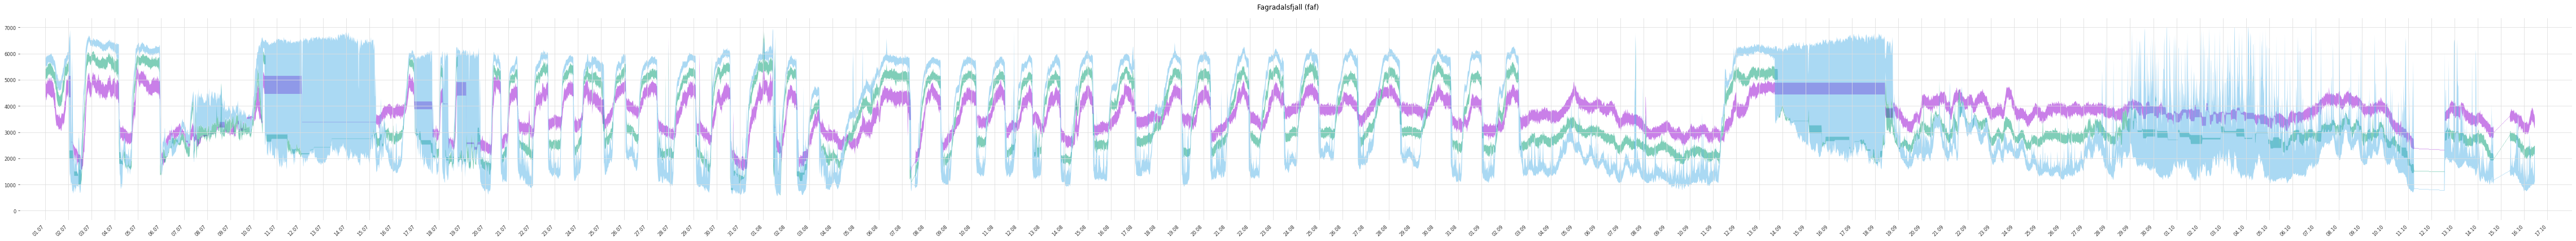

In [3]:
# -------------------------------------------------------------------------
#  Plot data & save
# -------------------------------------------------------------------------
fig, ax = all_data.create_plot(title="Fagradalsfjall (faf)")
fig.savefig(FILE_DATASET_FULL + ".png", dpi=450)

In [4]:
# --- PKL -------------------------------------------------
print("Saving dataset as .pkl".ljust(30), end="")
save_dataset_pickle(all_data)
print("Done.")

# --- CSV -------------------------------------------------
print("Saving dataset as .csv".ljust(30), end="")
save_dataset_csv(all_data)
print("Done.")

Saving dataset as .pkl                            Done.
Saving dataset as .csv                            Done.
